# Sudoku board frame debug split

Lekki notebook diagnostyczny oparty o lokalne moduly w `src/MachineLearning/draft`. Tutaj zostaje tylko konfiguracja i wizualizacja.

In [31]:
%matplotlib inline

from dataclasses import dataclass, field
from pathlib import Path
import math
import sys

print("import: cv2")
import cv2
import numpy as np

print("import: matplotlib")
import matplotlib.pyplot as plt

print("import: local draft modules")
DRAFT_DIR = Path("/home/wojtek/projects/sudoku/src/MachineLearning/draft")
if str(DRAFT_DIR) not in sys.path:
    sys.path.insert(0, str(DRAFT_DIR))

from sudoku_board_debug_core import (
    BoardDebugSettings,
    LineSegment,
    angle_difference_degrees,
    binarize_image,
    build_line_segment,
    fit_line,
    get_dominant_angle_degrees,
    get_line_normal,
    load_image,
    preprocess_image,
)
from sudoku_board_debug_visualization import show_image

print("imports: done")
plt.rcParams["figure.figsize"] = (18, 10)
plt.rcParams["image.cmap"] = "gray"


import: cv2
import: matplotlib
import: local draft modules
imports: done


In [32]:
# Wymagane biblioteki:
# /twoj/python -m pip install numpy matplotlib opencv-python


In [33]:
IMAGE_PATH = Path("/home/wojtek/projects/sudoku/data/raw/boards/v2_test/image18.jpg")

settings = BoardDebugSettings(
    grayscale_color_conversion_code=cv2.COLOR_BGR2GRAY,
    gaussian_kernel_size=(5, 5),
    gaussian_sigma_x=0.0,
    adaptive_threshold_block_size=11,
    adaptive_threshold_c=2,
)

RAW_HOUGH_THRESHOLD = 35
RAW_MIN_LINE_LENGTH_RATIO = 0.08
RAW_MAX_LINE_GAP_RATIO = 0.02
FAMILY_ANGLE_TOLERANCE_DEGREES = 20.0
MERGE_ANGLE_TOLERANCE_DEGREES = 6.0
MERGE_DISTANCE_PX = 10.0
MERGE_ENDPOINT_GAP_PX = 20.0
POST_MERGE_PROJECTION_DISTANCE_PX = 8.0
POST_MERGE_ENDPOINT_GAP_PX = 28.0
POST_MERGE_MIN_OVERLAP_RATIO = 0.45
MIN_MERGED_SPAN_RATIO = 0.16
MAX_MERGED_THICKNESS_PX = 18.0

print(f"IMAGE_PATH = {IMAGE_PATH}")
print("Notebook skupia sie tylko na znajdowaniu linii po adaptive threshold.")


IMAGE_PATH = /home/wojtek/projects/sudoku/data/raw/boards/v2_test/image18.jpg
Notebook skupia sie tylko na znajdowaniu linii po adaptive threshold.


Binary-only debug starts from adaptive threshold.
Image size: 640x480
Raw Hough threshold: 35
Raw min line length px: 38
Raw max line gap px: 10
Post-merge projection distance px: 8.0
Post-merge endpoint gap px: 28.0
Post-merge min overlap ratio: 0.45
Min merged span px: 77


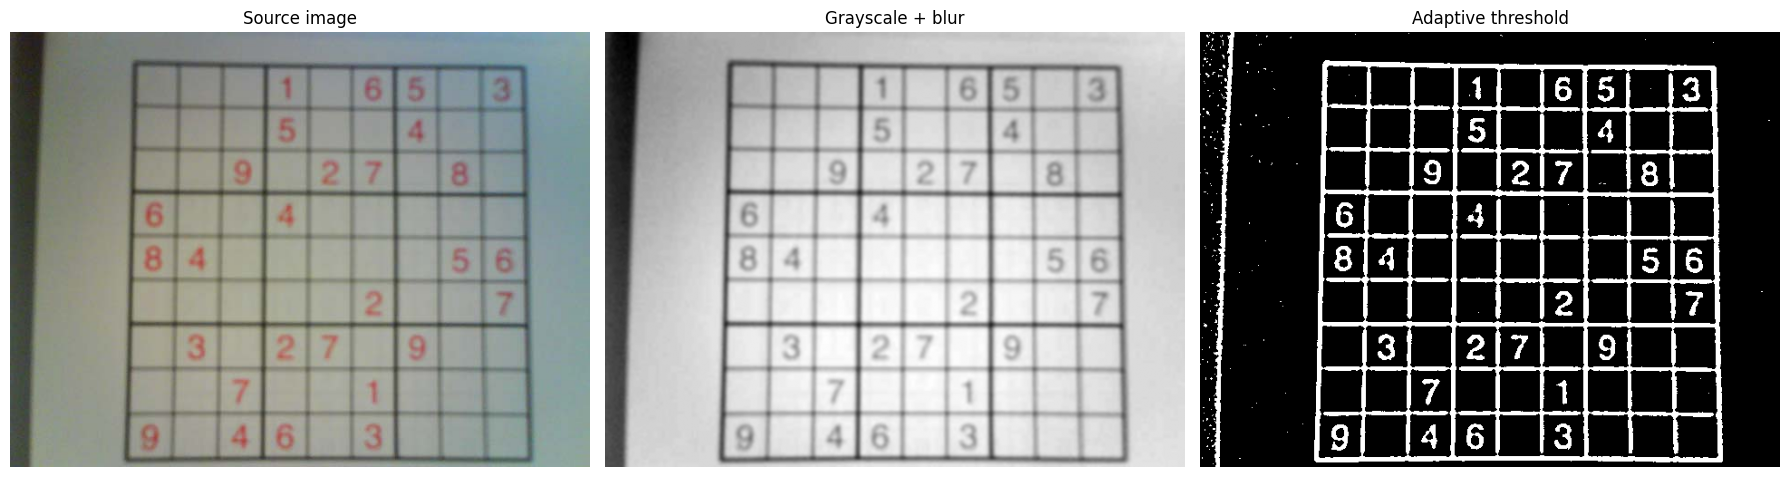

In [34]:
source_image = load_image(IMAGE_PATH)
preprocessed_image = preprocess_image(source_image, settings)
binary_image = binarize_image(preprocessed_image, settings)
binary_debug_image = cv2.cvtColor(binary_image, cv2.COLOR_GRAY2BGR)

image_height, image_width = binary_image.shape
minimum_dimension = min(image_height, image_width)
raw_min_line_length_px = max(
    8,
    int(round(minimum_dimension * RAW_MIN_LINE_LENGTH_RATIO)),
)
raw_max_line_gap_px = max(
    2,
    int(round(minimum_dimension * RAW_MAX_LINE_GAP_RATIO)),
)
min_merged_span_px = max(
    raw_min_line_length_px,
    int(round(minimum_dimension * MIN_MERGED_SPAN_RATIO)),
)

print("Binary-only debug starts from adaptive threshold.")
print(f"Image size: {image_width}x{image_height}")
print(f"Raw Hough threshold: {RAW_HOUGH_THRESHOLD}")
print(f"Raw min line length px: {raw_min_line_length_px}")
print(f"Raw max line gap px: {raw_max_line_gap_px}")
print(f"Post-merge projection distance px: {POST_MERGE_PROJECTION_DISTANCE_PX}")
print(f"Post-merge endpoint gap px: {POST_MERGE_ENDPOINT_GAP_PX}")
print(f"Post-merge min overlap ratio: {POST_MERGE_MIN_OVERLAP_RATIO}")
print(f"Min merged span px: {min_merged_span_px}")

figure, axes = plt.subplots(1, 3, figsize=(18, 6))
show_image(axes[0], source_image, "Source image", is_bgr=True)
show_image(axes[1], preprocessed_image, "Grayscale + blur")
show_image(axes[2], binary_image, "Adaptive threshold")
figure.tight_layout()


In [35]:
# Nowy eksperyment: szukamy wszystkich linii po adaptive threshold.
# Na tym etapie nie wybieramy ramki. Interesuje nas tylko:
# - wykrycie surowych fragmentow linii,
# - podzial na dwie glowne rodziny katow,
# - sklejenie fragmentow, gdy sa prawie rownolegle i blisko siebie,
# - dodatkowe sklejenie kandydatow, gdy jedna logiczna linia rozpadla sie na 2-3 byty.


@dataclass
class MergedLineCandidate:
    family_name: str
    family_angle_degrees: float
    segments: list[LineSegment] = field(default_factory=list)
    line: object | None = None
    projection: float = 0.0
    span_start: float = 0.0
    span_end: float = 0.0
    span_length: float = 0.0
    thickness_px: float = 0.0
    total_length: float = 0.0



def point_position_on_line(point, line):
    point_array = np.array(point, dtype=np.float32)
    return float(np.dot(point_array - line.point, line.direction))



def interval_gap(first_interval, second_interval):
    first_start, first_end = min(first_interval), max(first_interval)
    second_start, second_end = min(second_interval), max(second_interval)

    if first_end < second_start:
        return second_start - first_end
    if second_end < first_start:
        return first_start - second_end
    return 0.0



def interval_overlap(first_interval, second_interval):
    first_start, first_end = min(first_interval), max(first_interval)
    second_start, second_end = min(second_interval), max(second_interval)
    return max(0.0, min(first_end, second_end) - max(first_start, second_start))



def interval_length(interval):
    interval_start, interval_end = min(interval), max(interval)
    return interval_end - interval_start



def interval_overlap_ratio(first_interval, second_interval):
    shorter_length = min(
        interval_length(first_interval),
        interval_length(second_interval),
    )
    if shorter_length <= 1e-6:
        return 0.0
    return interval_overlap(first_interval, second_interval) / shorter_length



def merge_intervals(intervals):
    if not intervals:
        return []

    merged = [tuple(sorted(intervals[0]))]
    for start, end in intervals[1:]:
        start, end = min(start, end), max(start, end)
        previous_start, previous_end = merged[-1]
        if start <= previous_end:
            merged[-1] = (previous_start, max(previous_end, end))
        else:
            merged.append((start, end))
    return merged



def extract_raw_line_segments(
    binary_image,
    hough_threshold,
    min_line_length_px,
    max_line_gap_px,
):
    raw_segments = cv2.HoughLinesP(
        binary_image,
        rho=1,
        theta=np.pi / 180.0,
        threshold=hough_threshold,
        minLineLength=min_line_length_px,
        maxLineGap=max_line_gap_px,
    )
    if raw_segments is None:
        return []
    return [build_line_segment(raw_segment[0]) for raw_segment in raw_segments]



def collect_family_segments(line_segments, family_angle_degrees, angle_tolerance_degrees):
    return [
        line_segment
        for line_segment in line_segments
        if angle_difference_degrees(line_segment.angle_degrees, family_angle_degrees)
        <= angle_tolerance_degrees
    ]



def build_merged_candidate(family_name, family_angle_degrees, segments):
    fitted_line = fit_line(segments)
    # Projekcja musi byc liczona wzgledem stalej normalnej calej rodziny.
    # Gdy bierzemy normalna z fitted_line.direction, znak potrafi sie odwrocic
    # i ta sama pionowa linia wpada raz jako dodatnia, raz jako ujemna.
    line_normal = get_line_normal(family_angle_degrees)
    midpoint_projections = [
        float(np.dot(line_segment.midpoint(), line_normal))
        for line_segment in segments
    ]
    endpoint_positions = []
    for line_segment in segments:
        endpoint_positions.append(point_position_on_line(line_segment.start, fitted_line))
        endpoint_positions.append(point_position_on_line(line_segment.end, fitted_line))

    span_start = min(endpoint_positions)
    span_end = max(endpoint_positions)
    span_length = span_end - span_start
    thickness_px = 0.0
    if midpoint_projections:
        thickness_px = max(midpoint_projections) - min(midpoint_projections)

    return MergedLineCandidate(
        family_name=family_name,
        family_angle_degrees=family_angle_degrees,
        segments=list(segments),
        line=fitted_line,
        projection=float(np.mean(midpoint_projections)) if midpoint_projections else 0.0,
        span_start=float(span_start),
        span_end=float(span_end),
        span_length=float(span_length),
        thickness_px=float(thickness_px),
        total_length=float(sum(line_segment.length for line_segment in segments)),
    )



def segment_interval_on_candidate_line(line_segment, candidate):
    start_position = point_position_on_line(line_segment.start, candidate.line)
    end_position = point_position_on_line(line_segment.end, candidate.line)
    return (start_position, end_position)



def can_attach_segment(
    candidate,
    line_segment,
    merge_angle_tolerance_degrees,
    merge_distance_px,
    merge_endpoint_gap_px,
):
    if (
        angle_difference_degrees(
            line_segment.angle_degrees,
            candidate.family_angle_degrees,
        )
        > merge_angle_tolerance_degrees
    ):
        return False

    line_normal = get_line_normal(candidate.family_angle_degrees)
    segment_projection = float(np.dot(line_segment.midpoint(), line_normal))
    projection_distance = abs(segment_projection - candidate.projection)
    if projection_distance > merge_distance_px:
        return False

    candidate_interval = (candidate.span_start, candidate.span_end)
    segment_interval = segment_interval_on_candidate_line(line_segment, candidate)
    return interval_gap(candidate_interval, segment_interval) <= merge_endpoint_gap_px



def merge_parallel_segments(
    line_segments,
    family_angle_degrees,
    family_name,
    merge_angle_tolerance_degrees,
    merge_distance_px,
    merge_endpoint_gap_px,
):
    family_normal = get_line_normal(family_angle_degrees)
    sorted_segments = sorted(
        line_segments,
        key=lambda line_segment: (
            float(np.dot(line_segment.midpoint(), family_normal)),
            min(
                line_segment.start[0],
                line_segment.end[0],
                line_segment.start[1],
                line_segment.end[1],
            ),
        ),
    )

    merged_candidates = []
    for line_segment in sorted_segments:
        best_match_index = None
        best_match_score = None

        for candidate_index, candidate in enumerate(merged_candidates):
            if not can_attach_segment(
                candidate,
                line_segment,
                merge_angle_tolerance_degrees,
                merge_distance_px,
                merge_endpoint_gap_px,
            ):
                continue

            candidate_interval = (candidate.span_start, candidate.span_end)
            segment_interval = segment_interval_on_candidate_line(line_segment, candidate)
            family_normal = get_line_normal(candidate.family_angle_degrees)
            segment_projection = float(np.dot(line_segment.midpoint(), family_normal))
            score = (
                abs(segment_projection - candidate.projection),
                interval_gap(candidate_interval, segment_interval),
            )
            if best_match_score is None or score < best_match_score:
                best_match_score = score
                best_match_index = candidate_index

        if best_match_index is None:
            merged_candidates.append(
                build_merged_candidate(
                    family_name,
                    family_angle_degrees,
                    [line_segment],
                )
            )
            continue

        merged_segments = merged_candidates[best_match_index].segments + [line_segment]
        merged_candidates[best_match_index] = build_merged_candidate(
            family_name,
            family_angle_degrees,
            merged_segments,
        )

    return sorted(merged_candidates, key=lambda candidate: candidate.projection)



def can_merge_candidates(
    first_candidate,
    second_candidate,
    projection_merge_distance_px,
    endpoint_gap_px,
    min_overlap_ratio,
):
    projection_distance = abs(
        first_candidate.projection - second_candidate.projection
    )
    if projection_distance > projection_merge_distance_px:
        return False

    first_interval = (first_candidate.span_start, first_candidate.span_end)
    second_interval = (second_candidate.span_start, second_candidate.span_end)
    overlap_ratio = interval_overlap_ratio(first_interval, second_interval)
    if overlap_ratio >= min_overlap_ratio:
        return True

    return interval_gap(first_interval, second_interval) <= endpoint_gap_px



def merge_close_candidates(
    candidates,
    projection_merge_distance_px,
    endpoint_gap_px,
    min_overlap_ratio,
):
    sorted_candidates = sorted(candidates, key=lambda candidate: candidate.projection)
    merged_candidates = []

    for candidate in sorted_candidates:
        best_match_index = None
        best_match_score = None
        candidate_interval = (candidate.span_start, candidate.span_end)

        for candidate_index, existing_candidate in enumerate(merged_candidates):
            if not can_merge_candidates(
                existing_candidate,
                candidate,
                projection_merge_distance_px,
                endpoint_gap_px,
                min_overlap_ratio,
            ):
                continue

            existing_interval = (
                existing_candidate.span_start,
                existing_candidate.span_end,
            )
            overlap_ratio = interval_overlap_ratio(existing_interval, candidate_interval)
            score = (
                abs(existing_candidate.projection - candidate.projection),
                -overlap_ratio,
                interval_gap(existing_interval, candidate_interval),
            )
            if best_match_score is None or score < best_match_score:
                best_match_score = score
                best_match_index = candidate_index

        if best_match_index is None:
            merged_candidates.append(
                build_merged_candidate(
                    candidate.family_name,
                    candidate.family_angle_degrees,
                    candidate.segments,
                )
            )
            continue

        merged_segments = merged_candidates[best_match_index].segments + candidate.segments
        merged_candidates[best_match_index] = build_merged_candidate(
            candidate.family_name,
            candidate.family_angle_degrees,
            merged_segments,
        )

    return sorted(merged_candidates, key=lambda candidate: candidate.projection)



def filter_merged_candidates(candidates, min_span_px, max_thickness_px):
    return [
        candidate
        for candidate in candidates
        if candidate.span_length >= min_span_px
        and candidate.thickness_px <= max_thickness_px
    ]



def candidate_draw_points(candidate):
    start_point = candidate.line.point + candidate.line.direction * candidate.span_start
    end_point = candidate.line.point + candidate.line.direction * candidate.span_end
    return (
        (int(round(float(start_point[0]))), int(round(float(start_point[1])))),
        (int(round(float(end_point[0]))), int(round(float(end_point[1])))),
    )



def draw_raw_segments_overlay(base_image, line_segments):
    overlay = base_image.copy()
    for line_segment in line_segments:
        start_point = tuple(int(round(value)) for value in line_segment.start)
        end_point = tuple(int(round(value)) for value in line_segment.end)
        cv2.line(overlay, start_point, end_point, (180, 180, 180), 1)
    return overlay



def draw_family_overlay(base_image, primary_segments, secondary_segments):
    overlay = base_image.copy()
    for line_segment in primary_segments:
        start_point = tuple(int(round(value)) for value in line_segment.start)
        end_point = tuple(int(round(value)) for value in line_segment.end)
        cv2.line(overlay, start_point, end_point, (255, 165, 0), 1)
    for line_segment in secondary_segments:
        start_point = tuple(int(round(value)) for value in line_segment.start)
        end_point = tuple(int(round(value)) for value in line_segment.end)
        cv2.line(overlay, start_point, end_point, (0, 255, 255), 1)
    return overlay



def draw_merged_candidates_overlay(base_image, primary_candidates, secondary_candidates):
    overlay = base_image.copy()
    for family_prefix, candidates, color in (
        ("P", primary_candidates, (255, 0, 255)),
        ("S", secondary_candidates, (0, 220, 0)),
    ):
        for candidate_index, candidate in enumerate(candidates):
            start_point, end_point = candidate_draw_points(candidate)
            cv2.line(overlay, start_point, end_point, color, 2)
            anchor_x = int(round((start_point[0] + end_point[0]) / 2.0))
            anchor_y = int(round((start_point[1] + end_point[1]) / 2.0))
            label = f"{family_prefix}{candidate_index}|span={candidate.span_length:.0f}"
            cv2.putText(
                overlay,
                label,
                (max(10, anchor_x - 40), max(20, anchor_y - 4)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.45,
                color,
                1,
                cv2.LINE_AA,
            )
    return overlay



def describe_merged_candidates(candidates):
    return [
        (
            f"proj={candidate.projection:.1f}, span={candidate.span_length:.1f}, "
            f"thickness={candidate.thickness_px:.1f}, segments={len(candidate.segments)}, "
            f"len={candidate.total_length:.1f}"
        )
        for candidate in candidates
    ]



## Cel eksperymentu

Na tym etapie notebook szuka tylko wszystkich linii siatki. Ramke planszy wybierzemy dopiero pozniej, kiedy lista wykrytych i sklejonych linii bedzie stabilna.

Line finding experiment
Szukanie wszystkich linii po adaptive threshold, bez wybierania ramki.
Raw segments: 155
Primary family: 69 segments, angle= 0.00
Secondary family: 86 segments, angle= 90.00
Merged primary candidates: 11
Merged secondary candidates: 16
Filtered primary candidates: 11
Filtered secondary candidates: 12
Final primary candidates after post-merge: 10
Final secondary candidates after post-merge: 12

Primary candidates after first merge:
   proj=37.3, span=434.0, thickness=2.0, segments=6, len=1644.2
   proj=81.5, span=215.0, thickness=1.0, segments=2, len=345.0
   proj=84.7, span=436.0, thickness=4.0, segments=6, len=1561.0
   proj=130.9, span=437.0, thickness=2.0, segments=7, len=1414.3
   proj=178.0, span=436.0, thickness=6.0, segments=7, len=2166.0
   proj=225.9, span=440.0, thickness=3.0, segments=9, len=1511.2
   proj=273.9, span=441.0, thickness=5.0, segments=7, len=1975.0
   proj=322.5, span=440.0, thickness=5.0, segments=6, len=2101.0
   proj=371.0, span=445.0

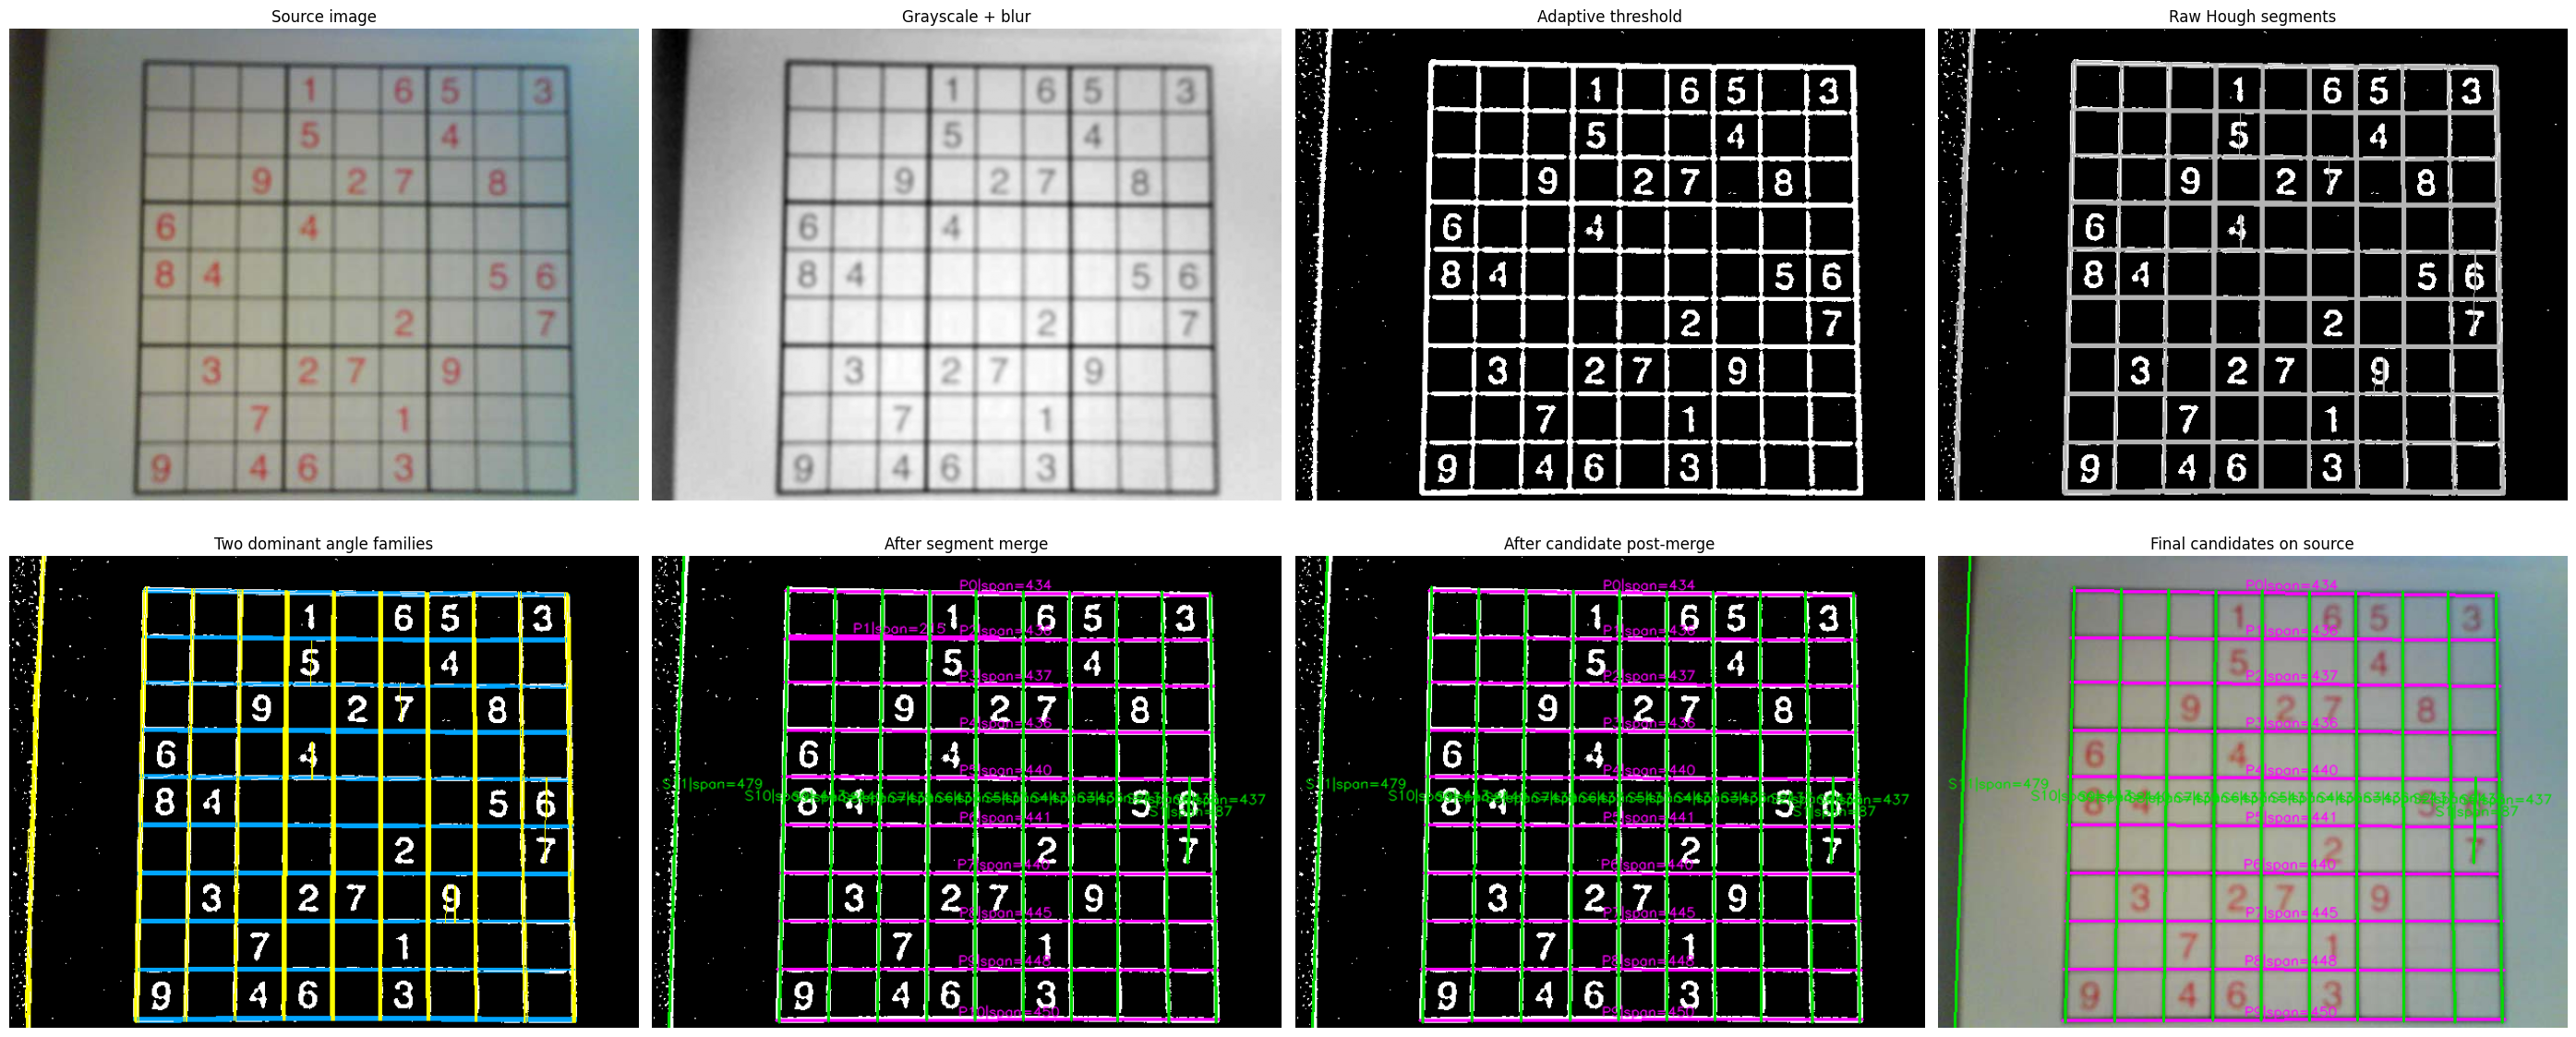

In [36]:
raw_line_segments = extract_raw_line_segments(
    binary_image,
    RAW_HOUGH_THRESHOLD,
    raw_min_line_length_px,
    raw_max_line_gap_px,
)
if not raw_line_segments:
    raise ValueError("Nie znaleziono zadnych surowych segmentow linii.")

primary_angle_degrees = get_dominant_angle_degrees(raw_line_segments)
secondary_angle_degrees = (primary_angle_degrees + 90.0) % 180.0

primary_raw_segments = collect_family_segments(
    raw_line_segments,
    primary_angle_degrees,
    FAMILY_ANGLE_TOLERANCE_DEGREES,
)
secondary_raw_segments = collect_family_segments(
    raw_line_segments,
    secondary_angle_degrees,
    FAMILY_ANGLE_TOLERANCE_DEGREES,
)

primary_merged_candidates = merge_parallel_segments(
    primary_raw_segments,
    primary_angle_degrees,
    "primary",
    MERGE_ANGLE_TOLERANCE_DEGREES,
    MERGE_DISTANCE_PX,
    MERGE_ENDPOINT_GAP_PX,
)
secondary_merged_candidates = merge_parallel_segments(
    secondary_raw_segments,
    secondary_angle_degrees,
    "secondary",
    MERGE_ANGLE_TOLERANCE_DEGREES,
    MERGE_DISTANCE_PX,
    MERGE_ENDPOINT_GAP_PX,
)

primary_filtered_candidates = filter_merged_candidates(
    primary_merged_candidates,
    min_merged_span_px,
    MAX_MERGED_THICKNESS_PX,
)
secondary_filtered_candidates = filter_merged_candidates(
    secondary_merged_candidates,
    min_merged_span_px,
    MAX_MERGED_THICKNESS_PX,
)

primary_final_candidates = filter_merged_candidates(
    merge_close_candidates(
        primary_filtered_candidates,
        POST_MERGE_PROJECTION_DISTANCE_PX,
        POST_MERGE_ENDPOINT_GAP_PX,
        POST_MERGE_MIN_OVERLAP_RATIO,
    ),
    min_merged_span_px,
    MAX_MERGED_THICKNESS_PX,
)
secondary_final_candidates = filter_merged_candidates(
    merge_close_candidates(
        secondary_filtered_candidates,
        POST_MERGE_PROJECTION_DISTANCE_PX,
        POST_MERGE_ENDPOINT_GAP_PX,
        POST_MERGE_MIN_OVERLAP_RATIO,
    ),
    min_merged_span_px,
    MAX_MERGED_THICKNESS_PX,
)

raw_segments_overlay = draw_raw_segments_overlay(binary_debug_image, raw_line_segments)
family_overlay_image = draw_family_overlay(
    binary_debug_image,
    primary_raw_segments,
    secondary_raw_segments,
)
segment_merge_overlay_image = draw_merged_candidates_overlay(
    binary_debug_image,
    primary_filtered_candidates,
    secondary_filtered_candidates,
)
final_merge_overlay_image = draw_merged_candidates_overlay(
    binary_debug_image,
    primary_final_candidates,
    secondary_final_candidates,
)
final_merge_overlay_on_source_image = draw_merged_candidates_overlay(
    source_image,
    primary_final_candidates,
    secondary_final_candidates,
)

print("Line finding experiment")
print("Szukanie wszystkich linii po adaptive threshold, bez wybierania ramki.")
print(f"Raw segments: {len(raw_line_segments)}")
print(
    "Primary family:",
    len(primary_raw_segments),
    "segments, angle=",
    f"{primary_angle_degrees:.2f}",
)
print(
    "Secondary family:",
    len(secondary_raw_segments),
    "segments, angle=",
    f"{secondary_angle_degrees:.2f}",
)
print("Merged primary candidates:", len(primary_merged_candidates))
print("Merged secondary candidates:", len(secondary_merged_candidates))
print("Filtered primary candidates:", len(primary_filtered_candidates))
print("Filtered secondary candidates:", len(secondary_filtered_candidates))
print("Final primary candidates after post-merge:", len(primary_final_candidates))
print("Final secondary candidates after post-merge:", len(secondary_final_candidates))

print("\nPrimary candidates after first merge:")
for description in describe_merged_candidates(primary_filtered_candidates):
    print("  ", description)

print("\nSecondary candidates after first merge:")
for description in describe_merged_candidates(secondary_filtered_candidates):
    print("  ", description)

print("\nPrimary candidates after post-merge:")
for description in describe_merged_candidates(primary_final_candidates):
    print("  ", description)

print("\nSecondary candidates after post-merge:")
for description in describe_merged_candidates(secondary_final_candidates):
    print("  ", description)

if len(primary_final_candidates) != 10 or len(secondary_final_candidates) != 10:
    print("\nUwaga: po post-merge nadal nie mamy idealnego ukladu 10x10.")
    print(
        "To jest oczekiwane na tym etapie: notebook ma pomoc pokazac,"
        " ktore kandydaty dalej sa zdublowane albo za slabe."
    )

figure, axes = plt.subplots(2, 4, figsize=(28, 12))
show_image(axes[0, 0], source_image, "Source image", is_bgr=True)
show_image(axes[0, 1], preprocessed_image, "Grayscale + blur")
show_image(axes[0, 2], binary_image, "Adaptive threshold")
show_image(axes[0, 3], raw_segments_overlay, "Raw Hough segments", is_bgr=True)
show_image(axes[1, 0], family_overlay_image, "Two dominant angle families", is_bgr=True)
show_image(
    axes[1, 1],
    segment_merge_overlay_image,
    "After segment merge",
    is_bgr=True,
)
show_image(
    axes[1, 2],
    final_merge_overlay_image,
    "After candidate post-merge",
    is_bgr=True,
)
show_image(
    axes[1, 3],
    final_merge_overlay_on_source_image,
    "Final candidates on source",
    is_bgr=True,
)
figure.tight_layout()

